In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working!")

Everything is working!


In [3]:
df = pd.read_csv("../data/US_Accidents_100k.csv")

In [4]:
df.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [17]:
df.shape

(100000, 47)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 47 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ID                     100000 non-null  str           
 1   Source                 100000 non-null  str           
 2   Severity               100000 non-null  int64         
 3   Start_Time             100000 non-null  datetime64[us]
 4   End_Time               100000 non-null  str           
 5   Start_Lat              100000 non-null  float64       
 6   Start_Lng              100000 non-null  float64       
 7   End_Lat                0 non-null       float64       
 8   End_Lng                0 non-null       float64       
 9   Distance(mi)           100000 non-null  float64       
 10  Description            100000 non-null  str           
 11  Street                 100000 non-null  str           
 12  City                   99999 non-null   str           
 

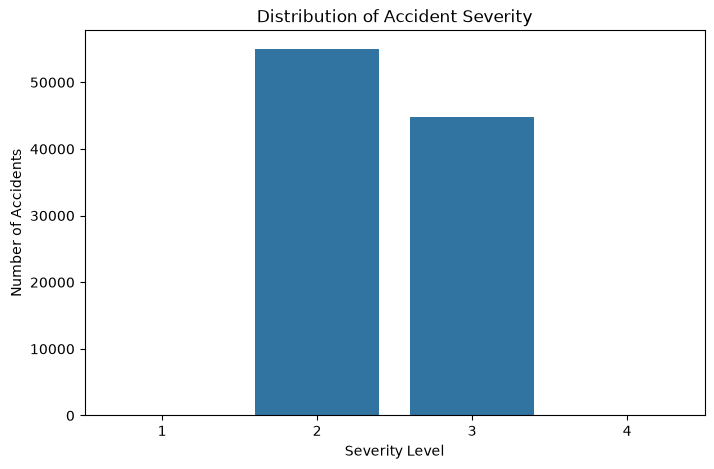

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.show()


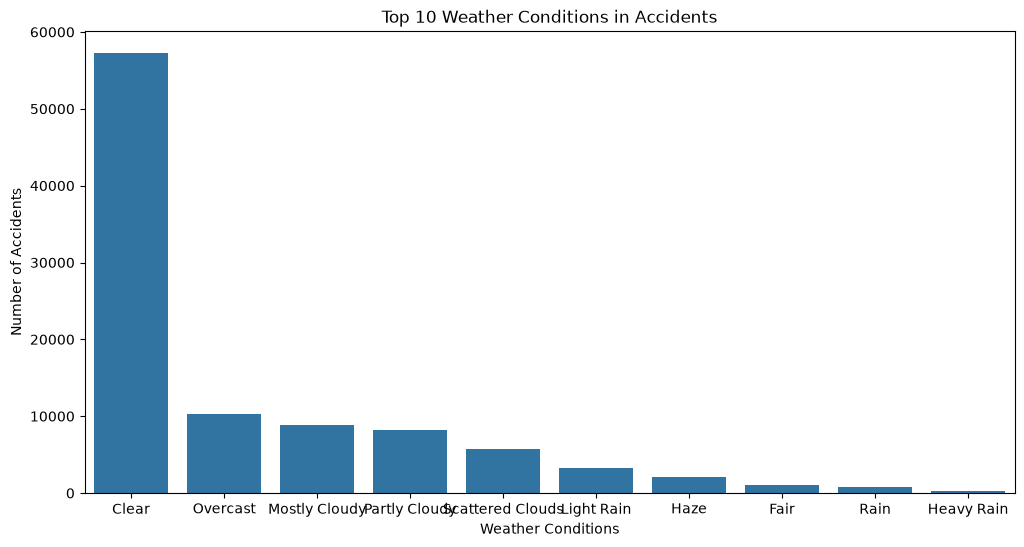

In [6]:
plt.figure(figsize=(12, 6))
top_weather = df['Weather_Condition'].value_counts().head(10)
sns.barplot(x=top_weather.index, y=top_weather.values)
plt.title('Top 10 Weather Conditions in Accidents')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')

plt.show()


ACCIDENT TIME ANALYSIS

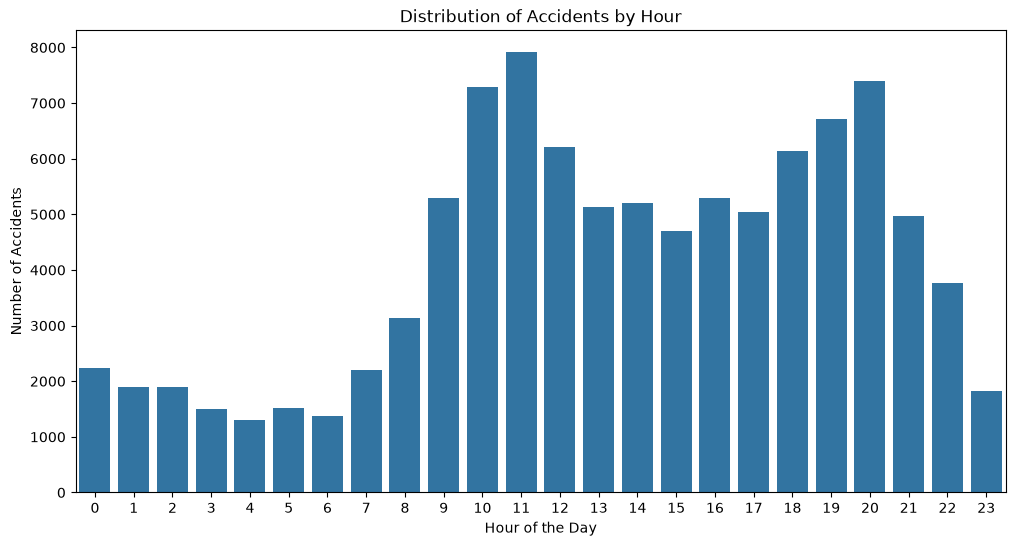

In [8]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

df["Hour"] = df["Start_Time"].dt.hour

plt.figure(figsize=(12, 6))
sns.countplot(x='Hour', data=df)
plt.title('Distribution of Accidents by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.show()


Observation: The highest number of accidents occurred at 11:00 AM. This suggests that accident frequency increases during the late morning, likely due to higher traffic volume and increased road activity during that time.

STATE WISE ACCIDENT DISTRIBUTION

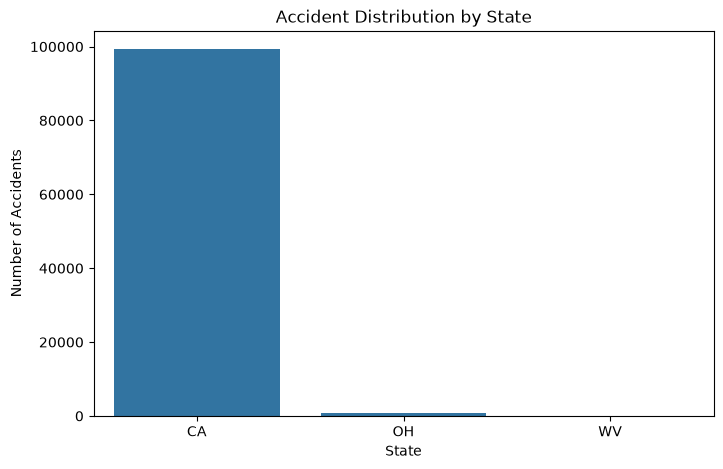

In [14]:
plt.figure(figsize=(8,5))

state_counts = df["State"].value_counts()

sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

plt.title("Accident Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Accidents")

plt.show()

In [11]:
df["State"].value_counts() 

State
CA    99272
OH      726
WV        2
Name: count, dtype: int64

Observation: The dataset contains accident records from three states: California (CA), West Virginia (WV), and Ohio (OH). California has the highest number of accidents among the three, indicating that it contributes the largest share of records in this dataset.

CORRELATION HEATMAP

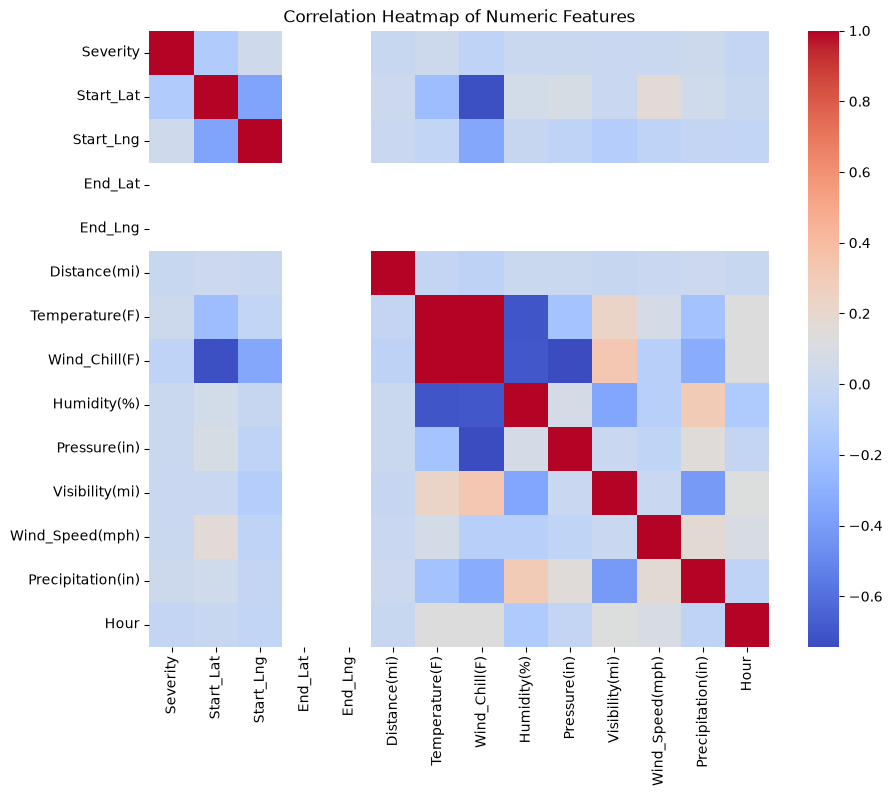

In [15]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False

)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Observation: The correlation heatmap shows the relationships between numerical features in the dataset. Most features have weak correlations, indicating that no single numerical feature strongly influences the others. This information is useful when selecting features for machine learning models.

In [19]:
df.describe()

,Severity,Start_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Hour
count,100000.000000,100000,100000.000000,100000.000000,0.0,0.0,100000.000000,98409.000000,4322.000000,98144.000000,98708.000000,98154.000000,76180.000000,7368.000000,100000.000000
mean,2.448120,2016-09-13 05:06:10.255490,35.630369,-119.322756,NaN,NaN,0.011345,66.641262,48.845812,59.794170,29.961021,9.338639,8.044165,0.025786,13.503180
min,1.000000,2016-02-08 05:46:00,32.542587,-123.813927,NaN,NaN,0.000000,3.200000,-8.400000,4.000000,2.980000,0.100000,0.000000,0.000000,0.000000
25%,2.000000,2016-07-19 10:51:31.250000,33.957775,-121.828468,NaN,NaN,0.000000,57.900000,37.100000,43.000000,29.890000,10.000000,4.600000,0.000000,10.000000
50%,2.000000,2016-09-18 18:18:02,34.168579,-118.384232,NaN,NaN,0.000000,66.000000,42.500000,62.000000,29.970000,10.000000,6.900000,0.000000,14.000000
75%,3.000000,2016-11-20 01:16:09.250000,37.776682,-117.916023,NaN,NaN,0.010000,75.000000,63.000000,78.000000,30.060000,10.000000,10.400000,0.030000,18.000000
max,4.000000,2017-01-26 20:07:03,41.428753,-81.550728,NaN,NaN,51.130000,114.100000,107.000000,100.000000,33.040000,80.000000,241.700000,0.550000,23.000000
std,0.499931,NaN,2.101259,3.663525,NaN,NaN,0.262244,12.703846,19.898270,23.184442,0.275672,1.885828,4.298926,0.051695,5.778614
